#### Map parcels by water use intensity

Calculates water use intensities for each parcel and maps them.

In [1]:
from pathlib import Path
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
from matplotlib.colors import SymLogNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch, Rectangle
import matplotlib.gridspec as gridspec

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/Parcel_maps_intensity")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- MANUAL SET UP ----------

# for the scenario you want included in the figure, set scenario name, run date

scenario = 'calibration'
GBSJ_run_date = '2026-07-16'
LCRR_run_date = '2026-07-16'
MILK_run_date = '2026-07-16'

year = 2020

In [3]:
##### ---------- IMPORT DATA ----------

### ----- PARCEL INTENSITY COMPONENTS -----

# parcel water use 
GBSJ_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_GBSJ/{scenario}-{GBSJ_run_date}_parcel/GBSJ-parcel-log.csv')
LCRR_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_LCRR/{scenario}-{LCRR_run_date}_parcel/LCRR-parcel-log.csv')
MILK_water_use = pd.read_csv(f'/netfiles/ciroh/kandrew6/Water_Use_Model/Outputs_MILK/{scenario}-{MILK_run_date}_parcel/MILK-parcel-log.csv')

GBSJ_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/GBSJ_parcel_land_use.csv')
LCRR_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/LCRR_parcel_land_use.csv')
MILK_land_use = pd.read_csv('/netfiles/ciroh/data/social_water_use/Land_Use_byParcel/MILK_parcel_land_use.csv')

### ----- GEO BOUNDARIES -----

# parcel  boundaries
GBSJ_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/GBSJ_with_ID.shp")
LCRR_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/LCRR_with_ID.shp")
MILK_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/MILK_with_ID.shp")

# huc12 boundaries 
GBSJ_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/GBSJ_basin.shp")
LCRR_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/LCRR_basin.shp")
MILK_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/MILK_basin.shp")

# prep CRS for maps
target_crs = GBSJ_basin.crs

LCRR_basin = LCRR_basin.to_crs(target_crs)
MILK_basin = MILK_basin.to_crs(target_crs)
GBSJ_parcels = GBSJ_parcels.to_crs(target_crs)
LCRR_parcels = LCRR_parcels.to_crs(target_crs)
MILK_parcels = MILK_parcels.to_crs(target_crs)

In [4]:
##### ---------- PREP INTENSITIES ----------

### ----- CLEAN DATA -----

# select year 
GBSJ_water_use = GBSJ_water_use[GBSJ_water_use['year'] == year].copy()
LCRR_water_use = LCRR_water_use[LCRR_water_use['year'] == year].copy()
MILK_water_use = MILK_water_use[MILK_water_use['year'] == year].copy()

GBSJ_land_use = GBSJ_land_use[GBSJ_land_use['Year'] == year].copy()
LCRR_land_use = LCRR_land_use[LCRR_land_use['Year'] == year].copy()
MILK_land_use = MILK_land_use[MILK_land_use['Year'] == year].copy()

# prep parcel ID
GBSJ_land_use['PARCEL_ID'] = GBSJ_land_use['PARCEL_ID'].str.replace('GBSJ_', '', regex=False).astype('int64')
LCRR_land_use['PARCEL_ID'] = LCRR_land_use['PARCEL_ID'].str.replace('LCRR_', '', regex=False).astype('int64')
MILK_land_use['PARCEL_ID'] = MILK_land_use['PARCEL_ID'].str.replace('MILK_', '', regex=False).astype('int64')

# merge 
GBSJ_intensitities = GBSJ_water_use.merge(GBSJ_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')
LCRR_intensitities = LCRR_water_use.merge(LCRR_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')
MILK_intensitities = MILK_water_use.merge(MILK_land_use[['PARCEL_ID', 'parcel_area_acres', 'parcel_class', 'acres_1', 'acres_2', 'acres_3', 'acres_4']], left_on='parcel_id', right_on='PARCEL_ID', how='outer')

### ----- CALCULATE ANNUAL INTENSITIES -----

#  Land cover categories:
#  1:  Wet ecosystems - Water, Perennial Ice/Snow, Wetland
#  2:  Other natural  - Barren Land, Deciduous/Evergreen/Mixed Forest, Shrubland, Grassland, Lichen Moss
#  3:  Agriculture     - Cropland/Pastureland
#  4:  Built-up        - Developed

for df in [GBSJ_intensitities, LCRR_intensitities, MILK_intensitities]:

    # Public supply (built-up land)
    df['public_supply_kgal_per_year_per_acre_built_up'] = np.where(
        (df['acres_4'] < 0.001) & df['public_supply_mil_gal'].notna(),
        0,
        (df['public_supply_mil_gal'] * 1e3) / df['acres_4']
    )

    # Irrigation (agricultural land)
    df['irrigation_kgal_per_year_per_acre_ag_land'] = np.where(
        (df['acres_3'] < 0.001) & df['irrigation_mil_gal'].notna(),
        0,
        (df['irrigation_mil_gal'] * 1e3) / df['acres_3']
    )

### ----- JOIN WITH GEO -----

# prep parcel ID's 
GBSJ_parcels['PARCEL_ID'] = GBSJ_parcels['PARCEL_ID'].str.replace('GBSJ_', '', regex=False).astype('int64')
LCRR_parcels['PARCEL_ID'] = LCRR_parcels['PARCEL_ID'].str.replace('LCRR_', '', regex=False).astype('int64')
MILK_parcels['PARCEL_ID'] = MILK_parcels['PARCEL_ID'].str.replace('MILK_', '', regex=False).astype('int64')

# merge 
GBSJ_parcels = GBSJ_parcels.merge(GBSJ_intensitities, on='PARCEL_ID', how='outer')
LCRR_parcels = LCRR_parcels.merge(LCRR_intensitities, on='PARCEL_ID', how='outer')
MILK_parcels = MILK_parcels.merge(MILK_intensitities, on='PARCEL_ID', how='outer')


### ----- FILL IN PARCEL CLASS -----

for df in [GBSJ_parcels, LCRR_parcels, MILK_parcels]:
    mask = (
        df['parcel_type'].isna() &
        (df['parcel_class'].isin([1, 2, 5]) | df['parcel_class'].isna())
    )
    df.loc[mask, 'parcel_type'] = 'other'

/tmp/ipykernel_3501616/4033446304.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 0.88, 0.95])


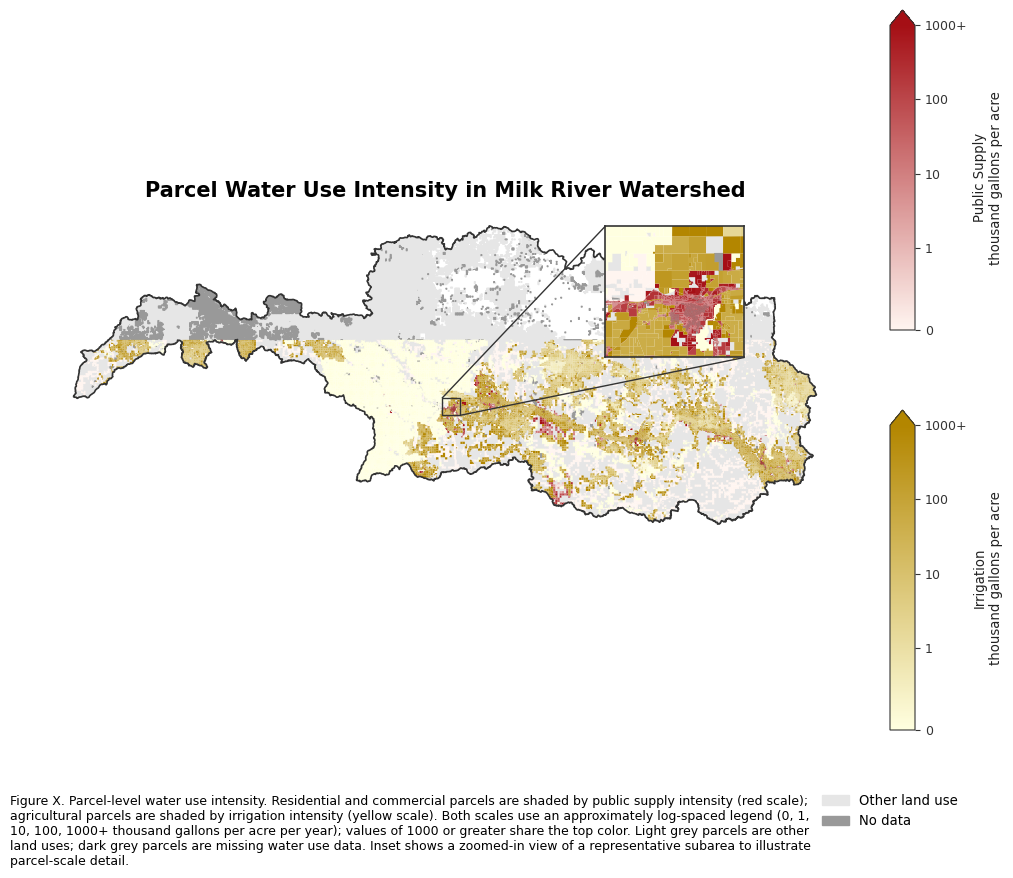

In [7]:
##### --------- MAP MILK PARCEL WATER USE INTENSITY ----------

# set figure to plot 
parcels = MILK_parcels.copy() # GBSJ_parcels, LCRR_parcels, MILK_parcels
basin = MILK_basin.copy() # GBSJ_basin, LCRR_basin, MILK_basin
watershed = 'Milk River' # Galveston Bay–San Jacinto, Lake Champlain–Richelieu River, or Milk River
watershed_code = 'MILK' #GBSJ, LCRR, or MILK

# set b_box 
# GBSJ = (-95.30603,29.38080,-95.21200,29.46013)
# LCRR = (-73.12375,44.45686,-73.03424,44.52832)
# MILK = (-109.78792,48.50831,-109.60905,48.61946)
bbox_wgs84 = box(-109.78792,48.50831,-109.60905,48.61946)

### ------ SET STYLE ----- 

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

OTHER_COLOR = '#e6e6e6'   # light grey, for parcel_type == 'other' with both water-use values missing
NO_DATA_COLOR = '#999999' # dark grey, for parcel_type missing with both water-use values missing

### ----- CLASSIFY PARCELS -----

is_res_com = parcels['parcel_type'].isin(['residential', 'commercial'])
is_ag = parcels['parcel_type'] == 'agricultural'

both_missing = (
    parcels['public_supply_kgal_per_year_per_acre_built_up'].isna()
    & parcels['irrigation_kgal_per_year_per_acre_ag_land'].isna()
)

# 1) light grey: parcel_type == 'other' AND both water-use fields missing
mask_other = (parcels['parcel_type'] == 'other') & both_missing

# 2) dark grey: parcel_type missing AND both water-use fields missing
mask_no_data = parcels['parcel_type'].isna() & both_missing

# 3) colored groups
mask_supply = is_res_com & parcels['public_supply_kgal_per_year_per_acre_built_up'].notna()
mask_irrigation = is_ag & parcels['irrigation_kgal_per_year_per_acre_ag_land'].notna()

# catch-all: anything not already classified (e.g. residential/commercial/agricultural
# parcels missing their relevant field, or 'other'/missing-type parcels where only one
# of the two fields is missing) — fold into "no data" so nothing is silently dropped
mask_classified = mask_other | mask_no_data | mask_supply | mask_irrigation
mask_uncaught = ~mask_classified
mask_no_data = mask_no_data | mask_uncaught

parcels_other = parcels[mask_other].copy()
parcels_no_data = parcels[mask_no_data].copy()
parcels_supply = parcels[mask_supply].copy()
parcels_irrigation = parcels[mask_irrigation].copy()

# clip at 1000 so anything >=1000 shares the top color
parcels_supply['plot_val'] = parcels_supply['public_supply_kgal_per_year_per_acre_built_up'].clip(lower=0, upper=1000)
parcels_irrigation['plot_val'] = parcels_irrigation['irrigation_kgal_per_year_per_acre_ag_land'].clip(lower=0, upper=1000)

### ----- COLOR SCALES -----
# custom light->dark reds / yellows so they read distinctly from each other
reds_cmap = LinearSegmentedColormap.from_list('reds_seq', ['#fff5f0', '#a50f15'])
yellows_cmap = LinearSegmentedColormap.from_list('yellows_seq', ['#ffffe0', '#b38600'])

# symlog norm gives near-equal visual spacing across 0 | 1 | 10 | 100 | 1000
# (linthresh=1 makes the 0-1 segment behave like one log decade)
norm = SymLogNorm(linthresh=1, linscale=1, vmin=0, vmax=1000, base=10)

### ----- PLOT -----
fig, ax = plt.subplots(figsize=(10, 10))

### Plot parcels, by group
parcels_other.plot(
    ax=ax, color=OTHER_COLOR, edgecolor=OTHER_COLOR,
    linewidth=0.6, zorder=1
)
parcels_no_data.plot(
    ax=ax, color=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR,
    linewidth=0.6, zorder=1
)
parcels_supply.plot(
    ax=ax, column='plot_val', cmap=reds_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)
parcels_irrigation.plot(
    ax=ax, column='plot_val', cmap=yellows_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)

# basin outline, styled to match watershed outline in choropleth figure
basin.boundary.plot(ax=ax, color="#333333", linewidth=1.2, zorder=3)

ax.set_title(
    f"Parcel Water Use Intensity in {watershed} Watershed",
    fontsize=15, fontweight='bold', pad=10
)
ax.set_axis_off()

### Plot inset 

bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_wgs84], crs="EPSG:4326").to_crs(target_crs)
minx, miny, maxx, maxy = bbox_gdf.total_bounds

axins = inset_axes(
    ax,
    width="40%",   
    height="40%",
    loc="upper right",
    borderpad=1,
)

parcels_other.plot(
    ax=axins, color=OTHER_COLOR, edgecolor=OTHER_COLOR,
    linewidth=0.8, zorder=1
)
parcels_no_data.plot(
    ax=axins, color=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR,
    linewidth=0.8, zorder=1
)
parcels_supply.plot(
    ax=axins, column='plot_val', cmap=reds_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)
parcels_irrigation.plot(
    ax=axins, column='plot_val', cmap=yellows_cmap, norm=norm,
    edgecolor='none', linewidth=0, zorder=2
)

basin.boundary.plot(ax=axins, color="#333333", linewidth=1.2, zorder=3)

axins.set_xlim(minx, maxx)
axins.set_ylim(miny, maxy)
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.2)

rect, c1, c2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="#333333", lw=1)
rect.set_clip_on(False)
c1.set_clip_on(False)
c2.set_clip_on(False)

rect.set_zorder(10)
c1.set_zorder(10)
c2.set_zorder(10)

### ----- LEGENDS (two colorbars, symlog ticks, arrow indicating 1000+) -----

tick_vals = [0, 1, 10, 100, 1000]
tick_labels = ['0', '1', '10', '100', '1000+']

cax_supply = fig.add_axes([0.90, 0.55, 0.025, 0.32])
sm_supply = ScalarMappable(norm=norm, cmap=reds_cmap)
sm_supply.set_array([])
cb_supply = fig.colorbar(sm_supply, cax=cax_supply, extend='max')
cb_supply.set_ticks(tick_vals)
cb_supply.set_ticklabels(tick_labels)
cb_supply.set_label('Public Supply\nthousand gallons per acre', fontsize=9.5)
cb_supply.ax.tick_params(labelsize=9)

cax_irrigation = fig.add_axes([0.90, 0.15, 0.025, 0.32])
sm_irrigation = ScalarMappable(norm=norm, cmap=yellows_cmap)
sm_irrigation.set_array([])
cb_irrigation = fig.colorbar(sm_irrigation, cax=cax_irrigation, extend='max')
cb_irrigation.set_ticks(tick_vals)
cb_irrigation.set_ticklabels(tick_labels)
cb_irrigation.set_label('Irrigation\nthousand gallons per acre', fontsize=9.5)
cb_irrigation.ax.tick_params(labelsize=9)

### ----- OTHER / NO DATA LEGEND -----

other_patch = Patch(facecolor=OTHER_COLOR, edgecolor=OTHER_COLOR, label='Other land use')
no_data_patch = Patch(facecolor=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR, label='No data')
fig.legend(
    handles=[other_patch, no_data_patch],
    loc='lower right',
    bbox_to_anchor=(0.98, 0.04),
    frameon=False,
    fontsize=9.5,
)

### ----- CAPTION -----
caption_text = (
    "Figure X. Parcel-level water use intensity. Residential and commercial parcels are shaded by public supply intensity (red scale);\n" 
    "agricultural parcels are shaded by irrigation intensity (yellow scale). Both scales use an approximately log-spaced legend (0, 1,\n" 
    "10, 100, 1000+ thousand gallons per acre per year); values of 1000 or greater share the top color. Light grey parcels are other\n"
    "land uses; dark grey parcels are missing water use data. Inset shows a zoomed-in view of a representative subarea to illustrate\n"
    "parcel-scale detail."
)
fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)
fig.tight_layout(rect=[0.03, 0.06, 0.88, 0.95])

plt.savefig(out_dir / f"{watershed_code}_parcel_water_intensity_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
##### --------- COMBINED FIGURE: PARCEL-SCALE WATER USE INTENSITY (GBSJ, LCRR, MILK) ----------

import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch, Rectangle

### ------ SET STYLE -----

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

OTHER_COLOR = '#e6e6e6'
NO_DATA_COLOR = '#999999'

reds_cmap = LinearSegmentedColormap.from_list('reds_seq', ['#fff5f0', '#a50f15'])
yellows_cmap = LinearSegmentedColormap.from_list('yellows_seq', ['#ffffe0', '#b38600'])
norm = SymLogNorm(linthresh=1, linscale=1, vmin=0, vmax=1000, base=10)
tick_vals = [0, 1, 10, 100, 1000]
tick_labels = ['0', '1', '10', '100', '1000+']

### ----- WATERSHED CONFIG -----

watersheds = {
    'GBSJ': {
        'parcels': GBSJ_parcels, 'basin': GBSJ_basin,
        'bbox_wgs84': box(-95.30603, 29.38080, -95.21200, 29.46013),
        'full_name': 'Galveston Bay–San Jacinto',
    },
    'LCRR': {
        'parcels': LCRR_parcels, 'basin': LCRR_basin,
        'bbox_wgs84': box(-73.12375, 44.45686, -73.03424, 44.52832),
        'full_name': 'Lake Champlain–Richelieu River',
    },
    'MILK': {
        'parcels': MILK_parcels, 'basin': MILK_basin,
        'bbox_wgs84': box(-109.78792, 48.50831, -109.60905, 48.61946),
        'full_name': 'Milk River',
    },
}

### ----- HELPER: DATA ASPECT RATIO (width / height) -----

def get_aspect(basin):
    minx, miny, maxx, maxy = basin.total_bounds
    return (maxx - minx) / (maxy - miny)

aspect_gbsj = get_aspect(watersheds['GBSJ']['basin'])
aspect_lcrr = get_aspect(watersheds['LCRR']['basin'])
aspect_milk = get_aspect(watersheds['MILK']['basin'])

### ----- HELPER: CLASSIFY PARCELS -----

def classify_parcels(parcels):
    is_res_com = parcels['parcel_type'].isin(['residential', 'commercial'])
    is_ag = parcels['parcel_type'] == 'agricultural'

    both_missing = (
        parcels['public_supply_kgal_per_year_per_acre_built_up'].isna()
        & parcels['irrigation_kgal_per_year_per_acre_ag_land'].isna()
    )

    mask_other = (parcels['parcel_type'] == 'other') & both_missing
    mask_no_data = parcels['parcel_type'].isna() & both_missing
    mask_supply = is_res_com & parcels['public_supply_kgal_per_year_per_acre_built_up'].notna()
    mask_irrigation = is_ag & parcels['irrigation_kgal_per_year_per_acre_ag_land'].notna()

    mask_classified = mask_other | mask_no_data | mask_supply | mask_irrigation
    mask_uncaught = ~mask_classified
    mask_no_data = mask_no_data | mask_uncaught

    parcels_other = parcels[mask_other].copy()
    parcels_no_data = parcels[mask_no_data].copy()
    parcels_supply = parcels[mask_supply].copy()
    parcels_irrigation = parcels[mask_irrigation].copy()

    parcels_supply['plot_val'] = parcels_supply['public_supply_kgal_per_year_per_acre_built_up'].clip(lower=0, upper=1000)
    parcels_irrigation['plot_val'] = parcels_irrigation['irrigation_kgal_per_year_per_acre_ag_land'].clip(lower=0, upper=1000)

    return parcels_other, parcels_no_data, parcels_supply, parcels_irrigation

### ----- HELPER: PLOT ONE WATERSHED PANEL (with inset) -----

def plot_watershed_panel(ax, code, cfg, data_aspect, inset_loc, mark_loc1, mark_loc2, inset_size="40%"):
    parcels = cfg['parcels']
    basin = cfg['basin']
    bbox_wgs84 = cfg['bbox_wgs84']

    p_other, p_nodata, p_supply, p_irrigation = classify_parcels(parcels)

    # main panel
    p_other.plot(ax=ax, color=OTHER_COLOR, edgecolor=OTHER_COLOR, linewidth=0.6, zorder=1)
    p_nodata.plot(ax=ax, color=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR, linewidth=0.6, zorder=1)
    p_supply.plot(ax=ax, column='plot_val', cmap=reds_cmap, norm=norm, edgecolor='none', linewidth=0, zorder=2)
    p_irrigation.plot(ax=ax, column='plot_val', cmap=yellows_cmap, norm=norm, edgecolor='none', linewidth=0, zorder=2)
    basin.boundary.plot(ax=ax, color="#333333", linewidth=1.2, zorder=3)

    # lock the axes box to the data's own aspect ratio so it fills its
    # gridspec cell exactly (cell size is chosen to match this aspect too)
    ax.set_box_aspect(1 / data_aspect)  # box_aspect = height/width
    ax.set_title(code, fontsize=14, fontweight='bold', pad=6)
    ax.set_axis_off()

    # inset
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_wgs84], crs="EPSG:4326").to_crs(target_crs)
    minx, miny, maxx, maxy = bbox_gdf.total_bounds

    axins = inset_axes(ax, width=inset_size, height=inset_size, loc=inset_loc, borderpad=1)

    p_other.plot(ax=axins, color=OTHER_COLOR, edgecolor=OTHER_COLOR, linewidth=0.8, zorder=1)
    p_nodata.plot(ax=axins, color=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR, linewidth=0.8, zorder=1)
    p_supply.plot(ax=axins, column='plot_val', cmap=reds_cmap, norm=norm, edgecolor='none', linewidth=0, zorder=2)
    p_irrigation.plot(ax=axins, column='plot_val', cmap=yellows_cmap, norm=norm, edgecolor='none', linewidth=0, zorder=2)
    basin.boundary.plot(ax=axins, color="#333333", linewidth=1.2, zorder=3)

    axins.set_xlim(minx, maxx)
    axins.set_ylim(miny, maxy)
    axins.set_xticks([])
    axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#333333")
        spine.set_linewidth(1.2)

    rect, c1, c2 = mark_inset(ax, axins, loc1=mark_loc1, loc2=mark_loc2, fc="none", ec="#333333", lw=1)
    rect.set_clip_on(False)
    c1.set_clip_on(False)
    c2.set_clip_on(False)
    rect.set_zorder(10)
    c1.set_zorder(10)
    c2.set_zorder(10)

### ----- FIGURE SIZING (derived from data aspect ratios so rows have no dead space) -----

H_top = 6.5  # inches, tune to taste
FW = H_top * (aspect_gbsj + aspect_lcrr)  # top row width so both panels exactly fill their box

milk_frac = 0.75  # MILK gets 75% of bottom row width, legend gets 25%
width_milk = FW * milk_frac
H_bottom = width_milk / aspect_milk

margin_frac = 0.16  # fraction of figure height reserved for suptitle + caption
FH = (H_top + H_bottom) / (1 - margin_frac)

fig = plt.figure(figsize=(FW, FH))

outer_gs = fig.add_gridspec(
    2, 1,
    height_ratios=[H_top, H_bottom],
    hspace=0.01,
    top=0.92, bottom=0.08,
)
top_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=outer_gs[0],
    width_ratios=[aspect_gbsj, aspect_lcrr], wspace=0.02,
)
bottom_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=outer_gs[1],
    width_ratios=[milk_frac, 1 - milk_frac], wspace=0.02,
)

ax_gbsj = fig.add_subplot(top_gs[0])
ax_lcrr = fig.add_subplot(top_gs[1])
ax_milk = fig.add_subplot(bottom_gs[0])
ax_legend = fig.add_subplot(bottom_gs[1])

fig.suptitle("Parcel-Scale Water Use Intensity", fontsize=19, fontweight='bold', y=0.975)

# GBSJ - inset upper right
plot_watershed_panel(ax_gbsj, 'GBSJ', watersheds['GBSJ'], aspect_gbsj,
                      inset_loc='upper right', mark_loc1=2, mark_loc2=4)

# LCRR - inset upper LEFT now
plot_watershed_panel(ax_lcrr, 'LCRR', watersheds['LCRR'], aspect_lcrr,
                      inset_loc='upper left', mark_loc1=1, mark_loc2=3)

# MILK - inset lower left
plot_watershed_panel(ax_milk, 'MILK', watersheds['MILK'], aspect_milk,
                      inset_loc='lower left', mark_loc1=1, mark_loc2=3, inset_size="32%")

### ----- SHARED LEGEND PANEL -----

ax_legend.set_axis_off()

cax_supply = ax_legend.inset_axes([0.10, 0.72, 0.80, 0.06])
sm_supply = ScalarMappable(norm=norm, cmap=reds_cmap)
sm_supply.set_array([])
cb_supply = fig.colorbar(sm_supply, cax=cax_supply, orientation='horizontal', extend='max')
cb_supply.set_ticks(tick_vals)
cb_supply.set_ticklabels(tick_labels)
cb_supply.ax.tick_params(labelsize=8.5)
ax_legend.text(0.10, 0.81, 'Public Supply', transform=ax_legend.transAxes, fontsize=10, fontweight='bold', va='bottom')

cax_irrigation = ax_legend.inset_axes([0.10, 0.52, 0.80, 0.06])
sm_irrigation = ScalarMappable(norm=norm, cmap=yellows_cmap)
sm_irrigation.set_array([])
cb_irrigation = fig.colorbar(sm_irrigation, cax=cax_irrigation, orientation='horizontal', extend='max')
cb_irrigation.set_ticks(tick_vals)
cb_irrigation.set_ticklabels(tick_labels)
cb_irrigation.ax.tick_params(labelsize=8.5)
ax_legend.text(0.10, 0.61, 'Irrigation', transform=ax_legend.transAxes, fontsize=10, fontweight='bold', va='bottom')

ax_legend.text(0.50, 0.44, 'thousand gallons per acre per year', transform=ax_legend.transAxes,
                fontsize=9, ha='center', va='top', style='italic')

swatch_size = 0.07
sw_x = 0.10
other_y = 0.28
nodata_y = 0.16

ax_legend.add_patch(Rectangle((sw_x, other_y), swatch_size, swatch_size,
                               transform=ax_legend.transAxes, facecolor=OTHER_COLOR, edgecolor=OTHER_COLOR))
ax_legend.text(sw_x + swatch_size + 0.03, other_y + swatch_size / 2, 'Other land use',
               transform=ax_legend.transAxes, fontsize=9.5, va='center')

ax_legend.add_patch(Rectangle((sw_x, nodata_y), swatch_size, swatch_size,
                               transform=ax_legend.transAxes, facecolor=NO_DATA_COLOR, edgecolor=NO_DATA_COLOR))
ax_legend.text(sw_x + swatch_size + 0.03, nodata_y + swatch_size / 2, 'No data',
               transform=ax_legend.transAxes, fontsize=9.5, va='center')

### ----- CAPTION -----

caption_text = (
    "Figure X. Parcel-level water use intensity across three watersheds: GBSJ (Galveston Bay–San Jacinto), LCRR (Lake\n"
    "Champlain–Richelieu River), and MILK (Milk River). Residential and commercial parcels are shaded by public supply\n"
    "intensity (red scale); agricultural parcels are shaded by irrigation intensity (yellow scale). Both scales use an\n"
    "approximately log-spaced legend (0, 1, 10, 100, 1000+ thousand gallons per acre per year); values of 1000 or greater\n"
    "share the top color. Light grey parcels are other land uses; dark grey parcels are missing water use data. Insets\n"
    "show a zoomed-in view of a representative subarea within each watershed to illustrate parcel-scale detail."
)
fig.text(0.02, 0.01, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)

plt.savefig(out_dir / "ALL_parcel_water_intensity_map.png", dpi=300, bbox_inches="tight")
plt.show()